# Tutorial 03: TreeSHAP with an explicit output contract

This tutorial is deterministic, CPU-only, and offline. It uses scikit-learn's built-in breast-cancer dataset and the current Explainiverse TreeShapExplainer API. Every code cell is intended to run in order from a repository environment whose dependencies are already installed; the notebook never downloads data or installs packages.

## What this tutorial establishes

We will train one seeded random forest, explain one explicitly selected output column, verify TreeSHAP's additive accounting against the model output, contrast path-dependent and interventional feature-absence games, and use the separate batch API.

The required runtime dependencies are Explainiverse, NumPy, scikit-learn, SHAP, and Matplotlib. TreeSHAP values are local associations under a particular model, output space, and feature-perturbation game. They are not causal effects, and an additivity check is an accounting test rather than proof that an explanation is useful or faithful.

In [1]:
import platform

import matplotlib.pyplot as plt
import numpy as np
import shap
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import explainiverse
from explainiverse.adapters import SklearnAdapter
from explainiverse.explainers.attribution import TreeShapExplainer

SEED = 17
np.random.seed(SEED)

print(f"Python:         {platform.python_version()}")
print(f"Explainiverse: {explainiverse.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"SHAP:          {shap.__version__}")

Python:         3.12.2
Explainiverse: 0.14.0
scikit-learn:  1.7.2
SHAP:          0.52.0


## 1. Load local data and fit a reproducible model

load_breast_cancer() ships with scikit-learn, so this step has no network dependency. Fixed split and estimator seeds make the data partition and fitted forest reproducible. n_jobs=1 avoids environment-dependent parallel scheduling and is still fast for this small dataset.

In [2]:
dataset = load_breast_cancer()
X = np.asarray(dataset.data, dtype=np.float64)
y = np.asarray(dataset.target)
feature_names = [str(name) for name in dataset.feature_names]
class_names = [str(name) for name in dataset.target_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED,
)

model = RandomForestClassifier(
    n_estimators=64,
    max_depth=6,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=1,
)
model.fit(X_train, y_train)

adapter = SklearnAdapter(
    model,
    feature_names=feature_names,
    class_names=class_names,
    task="classification",
)

test_accuracy = float(model.score(X_test, y_test))
assert X_train.ndim == 2 and X_train.shape[1] == len(feature_names)
assert np.isfinite(X_train).all() and np.isfinite(X_test).all()
assert adapter.predict(X_test[:3]).shape == (3, len(class_names))
assert 0.0 <= test_accuracy <= 1.0
print(f"train rows: {len(X_train)}, test rows: {len(X_test)}")
print(f"features:   {len(feature_names)}")
print(f"test accuracy (descriptive): {test_accuracy:.3f}")

train rows: 426, test rows: 143
features:   30
test accuracy (descriptive): 0.986


## 2. Explain exactly one instance and one output

TreeShapExplainer.explain accepts one feature vector, represented as shape (n_features,) or (1, n_features). It rejects a multi-row matrix; use explain_batch for that. For classification, target_class is an integer **output-column index**, not an arbitrary class label. The column ordering follows model.classes_; class_names supplies display names only.

We use the default path-dependent game and explicitly fix the explained output. This makes later comparisons unambiguous.

In [3]:
test_instance = np.asarray(X_test[0], dtype=np.float64)
instance_probabilities = adapter.predict(test_instance.reshape(1, -1))[0]
target_output_index = int(np.argmax(instance_probabilities))

assert test_instance.shape == (len(feature_names),)
assert 0 <= target_output_index < len(model.classes_)

path_explainer = TreeShapExplainer(
    model=adapter,
    feature_names=feature_names,
    class_names=class_names,
    task="classification",
    model_output="auto",
    feature_perturbation="tree_path_dependent",
)
path_explanation = path_explainer.explain(
    test_instance,
    target_class=target_output_index,
    check_additivity=True,
)

path_data = path_explanation.explanation_data
path_attributions = path_data["feature_attributions"]

assert path_explanation.target_class == class_names[target_output_index]
assert path_data["class_index"] == target_output_index
assert path_data["feature_perturbation"] == "tree_path_dependent"
assert list(path_attributions) == feature_names
assert np.isfinite(np.fromiter(path_attributions.values(), dtype=float)).all()

print(f"model classes:          {model.classes_.tolist()}")
print(f"selected output index:  {target_output_index}")
print(f"selected display name:  {path_explanation.target_class}")
print(f"selected probability:   {instance_probabilities[target_output_index]:.6f}")
print(f"reported output space:  {path_data['output_space']}")

model classes:          [0, 1]
selected output index:  0
selected display name:  malignant
selected probability:   0.887463
reported output space:  probability


## 3. Verify additive accounting

For this audited scikit-learn random-forest configuration, the selected-output SHAP values should satisfy

$$\text{base value} + \sum_j \phi_j(x) \approx f_k(x),$$

where k is the explicit output-column index. Explainiverse records the reconstructed value, a concrete model reference value, and their residual. The assertions below check all four views of the same quantity. Passing them confirms numerical additivity in this mode; it does not establish a causal interpretation or prove that the coalition game matches a deployment intervention.

In [4]:
path_vector = np.array(
    [path_attributions[name] for name in feature_names],
    dtype=np.float64,
)
reconstructed_value = float(path_data["base_value"] + path_vector.sum())
reference_value = path_data["model_reference_value"]
residual = path_data["additivity_residual"]

assert reference_value is not None
assert residual is not None
np.testing.assert_allclose(
    reconstructed_value, path_data["explained_value"], rtol=0.0, atol=1e-10
)
np.testing.assert_allclose(
    reconstructed_value, reference_value, rtol=0.0, atol=1e-8
)
np.testing.assert_allclose(
    reference_value,
    instance_probabilities[target_output_index],
    rtol=0.0,
    atol=1e-8,
)
np.testing.assert_allclose(residual, 0.0, rtol=0.0, atol=1e-8)

print(f"base value:            {path_data['base_value']:.9f}")
print(f"sum of SHAP values:    {path_vector.sum():.9f}")
print(f"reconstructed output:  {reconstructed_value:.9f}")
print(f"model reference:       {reference_value:.9f}")
print(f"additivity residual:   {residual:.3e}")

base value:            0.373532864
sum of SHAP values:    0.513929934
reconstructed output:  0.887462798
model reference:       0.887462798
additivity residual:   0.000e+00


## 4. Change the feature-absence game deliberately

Path-dependent TreeSHAP uses counts along the fitted trees' paths to represent missing features. Interventional TreeSHAP instead integrates over an explicit background dataset and is sensitive to that dataset's composition. These are different cooperative games, so their attributions need not match. On the repository's locked dependency stack, this configured example has a small observed probability-space reconstruction residual. The code checks it against a prespecified tutorial regression bound; that bound is not a method-wide TreeSHAP guarantee and does not establish why the residual occurs.

Here the background is a fixed slice of the seeded training split. It is a compact tutorial reference distribution, not a claim that the first 48 rows are representative of a real deployment population.

In [5]:
background = np.asarray(X_train[:48], dtype=np.float64)
interventional_explainer = TreeShapExplainer(
    model=adapter,
    feature_names=feature_names,
    class_names=class_names,
    background_data=background,
    task="classification",
    model_output="probability",
    feature_perturbation="interventional",
)
interventional_explanation = interventional_explainer.explain(
    test_instance,
    target_class=target_output_index,
    check_additivity=False,
)

interventional_data = interventional_explanation.explanation_data
interventional_vector = np.array(
    [
        interventional_data["feature_attributions"][name]
        for name in feature_names
    ],
    dtype=np.float64,
)

assert interventional_data["feature_perturbation"] == "interventional"
assert interventional_data["output_space"] == "probability"
assert interventional_data["additivity_residual"] is not None
interventional_residual = float(interventional_data["additivity_residual"])
INTERVENTIONAL_TUTORIAL_REGRESSION_BOUND = 2e-4
assert np.isfinite(interventional_residual)
assert abs(interventional_residual) <= INTERVENTIONAL_TUTORIAL_REGRESSION_BOUND, (
    "interventional probability reconstruction exceeded this tutorial's "
    f"locked-stack regression bound: {interventional_residual:.3e}"
)

print(f"background rows:                  {len(background)}")
print(
    "interventional additivity residual: "
    f"{interventional_residual:.3e} "
    f"(tutorial bound {INTERVENTIONAL_TUTORIAL_REGRESSION_BOUND:.1e})"
)
print(
    "L1 distance between game-specific attribution vectors: "
    f"{np.abs(path_vector - interventional_vector).sum():.6f}"
)

background rows:                  48
interventional additivity residual: -1.085e-04 (tutorial bound 2.0e-04)
L1 distance between game-specific attribution vectors: 0.194030


## 5. Inspect the selected local explanation

The signed bars below describe contributions to the selected output for one person under the path-dependent game. Positive values raise that output relative to its base value; negative values lower it. Ranking by absolute magnitude is a local visualization choice, not global feature importance.

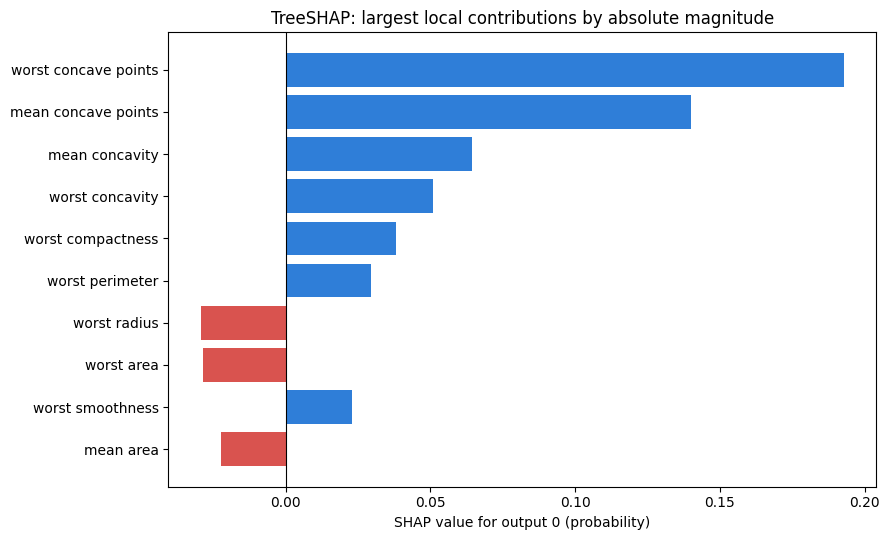

In [6]:
top_count = 10
top_indices = np.argsort(np.abs(path_vector))[-top_count:]
top_values = path_vector[top_indices]
top_names = [feature_names[index] for index in top_indices]
colors = ["#2f7ed8" if value >= 0 else "#d9534f" for value in top_values]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(np.arange(top_count), top_values, color=colors)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_yticks(np.arange(top_count), labels=top_names)
ax.set_xlabel(f"SHAP value for output {target_output_index} ({path_data['output_space']})")
ax.set_title("TreeSHAP: largest local contributions by absolute magnitude")
fig.tight_layout()
plt.show()

## 6. Keep single-instance and batch semantics separate

The guarded call first confirms that .explain() rejects a two-row matrix. .explain_batch() is then used for four rows with one fixed output index, which makes the results comparable across rows. Repeating the local call also checks determinism for this fixed model, instance, target, and mode.

In [7]:
multirow_was_rejected = False
try:
    path_explainer.explain(X_test[:2], target_class=target_output_index)
except ValueError:
    multirow_was_rejected = True
assert multirow_was_rejected, "explain() must reject a multi-row matrix"

batch = np.asarray(X_test[:4], dtype=np.float64)
batch_explanations = path_explainer.explain_batch(
    batch,
    target_class=target_output_index,
    check_additivity=True,
)
assert len(batch_explanations) == len(batch)
assert all(
    item.explanation_data["class_index"] == target_output_index
    for item in batch_explanations
)
batch_residuals = np.array(
    [item.explanation_data["additivity_residual"] for item in batch_explanations],
    dtype=np.float64,
)
assert np.isfinite(batch_residuals).all()
assert np.max(np.abs(batch_residuals)) < 1e-8

repeated = path_explainer.explain(
    test_instance.copy(),
    target_class=target_output_index,
    check_additivity=True,
)
repeated_vector = np.array(
    [repeated.explanation_data["feature_attributions"][name] for name in feature_names]
)
np.testing.assert_allclose(repeated_vector, path_vector, rtol=0.0, atol=1e-12)

print("multi-row local call rejected: yes")
print(f"batch explanations:             {len(batch_explanations)}")
print(f"maximum batch residual:         {np.max(np.abs(batch_residuals)):.3e}")
print("repeat attribution check:       exact within 1e-12")

multi-row local call rejected: yes
batch explanations:             4
maximum batch residual:         1.540e-17
repeat attribution check:       exact within 1e-12


## Interpretation boundaries and next steps

- This notebook stays inside the repository's accuracy-audited scope for selected scikit-learn tree estimators. Recognition of another estimator family by the wrapper does not by itself place that family inside the verified claim scope.
- Additivity is mode- and output-specific. It verifies that contributions plus the base value reconstruct the selected model output; it does not verify causal validity, robustness, fairness, or human usefulness.
- Path-dependent and interventional explanations answer different feature-absence questions. An interventional result depends on the supplied background distribution.
- Correlated or redundant predictors can divide credit in ways that are unstable under model retraining or a changed background.
- This is a one-instance, one-output explanation. Do not call its magnitude ranking global importance. Any aggregation must keep the target output, output space, perturbation game, data population, and preprocessing aligned.
- class_names are labels for presentation. Programmatic targeting uses an integer output index ordered like model.classes_.

A useful extension is to repeat the interventional explanation with several defensible background samples and report attribution variability while keeping the model, instances, output index, and output space fixed.